# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**1.** Множество выпуклое. Пусть $x, y$ принадлежат множеству и $0 \le t \le 1$. Тогда для точки $z = tx + (1-t)y$:

$z_2 = tx_2 + (1-t)y_2 \ge tx_1^2 + (1-t)y_1^2 \ge (tx_1 + (1-t)y_1)^2 = z_1^2$.

Последнее неравенство следует из выпуклости квадрата. Таким образом, весь отрезок принадлежит множеству.

**2.** Множество выпуклое. Для любых допустимых $x, y$:

$||A(tx + (1-t)y)-b||_2 = ||t(Ax-b)+(1-t)(Ay-b)||_2 \le t||Ax-b||_2+(1-t)||Ay-b||_2 \le 1$.

Использовали неравенство треугольника и $0 \le t \le 1$.

**3.** Множество невыпуклое. Точки $x=(1,0)$ и $y=(-1,0)$ принадлежат множеству, но их середина $(0,0)$ не принадлежит, поскольку её норма равна 0.

**(б)**

**1.** Найдем гессиан:

$\nabla^2 f(x) = \begin{pmatrix} 2 & a \\ a & 2 \end{pmatrix}$.

Собственные значения находятся из $(2-\lambda)^2-a^2=0$, то есть $\lambda_1=2+a$, $\lambda_2=2-a$. Для выпуклости оба должны быть неотрицательными:

$2+a \ge 0,\ 2-a \ge 0 \rightarrow -2 \le a \le 2$.

При $-2<a<2$ оба собственных значения положительны, поэтому функция строго выпуклая. При $a=2$ имеем $f(x)=(x_1+x_2)^2$, а при $a=-2$ имеем $f(x)=(x_1-x_2)^2$. На прямых $x_1=-x_2$ и $x_1=x_2$ соответственно функция постоянна, поэтому строгой выпуклости нет.

**2.** Функция невыпуклая:

$\nabla^2 g(x)=\begin{pmatrix} 2x_2^2 & 4x_1x_2 \\ 4x_1x_2 & 2x_1^2 \end{pmatrix}$.

В точке $(1,1)$ получаем матрицу $\begin{pmatrix}2&4\\4&2\end{pmatrix}$ с собственными значениями $6$ и $-2$. Гессиан не является положительно полуопределенным.

In [2]:
for a_value in [-3, -2, -1, 0, 1, 2, 3]:
    H = np.array([[2.0, a_value], [a_value, 2.0]])
    eigenvalues = np.linalg.eigvalsh(H)
    print(f'a = {a_value}: собственные значения {eigenvalues}')

a = -3: собственные значения [-1.  5.]
a = -2: собственные значения [0. 4.]
a = -1: собственные значения [1. 3.]
a = 0: собственные значения [2. 2.]
a = 1: собственные значения [1. 3.]
a = 2: собственные значения [0. 4.]
a = 3: собственные значения [-1.  5.]


**(в)**

**1.** Функция выпуклая. Норма является выпуклой функцией, а подстановка аффинного выражения $Ax-b$ сохраняет выпуклость. Функция $||x||_\infty$ тоже выпуклая, поэтому при $\lambda \ge 0$ их сумма выпуклая.

**2.** Каждая функция $(a_i^T x-b_i)^2$ выпуклая, поскольку это квадрат аффинной функции. Максимум выпуклых функций является выпуклым.

**3.** Правило композиции здесь не подходит: экспонента выпуклая и возрастающая, но $-||x||_2^2$ является вогнутой функцией. Возьмем $x=(1,0,\dots,0)$ и $y=-x$. Тогда $f(x)=f(y)=e^{-1}$, но $f((x+y)/2)=f(0)=1>e^{-1}$. Следовательно, функция невыпуклая.

**Гладкость.** Третья функция гладкая на всей области. Первая и вторая в общем случае негладкие: для первой пример $|x|$ при $A=1$, $b=0$, $\lambda=0$; для второй $\max\{(x-1)^2,(x+1)^2\}$ имеет разные левую и правую производные в нуле. При отдельных значениях параметров они могут быть гладкими.

**(г)**

**(а)** Задача выпуклая: цель $||x-(1,2,3)||_2^2$ имеет гессиан $2I$, равенства $x_1+x_2+x_3-1=0$ и $x_1-x_3=0$ аффинные. Неравенств нет.

**(б)** Задача выпуклая: цель $c^T x$ линейная, равенств нет, неравенства $Ax-b \ge 0$ и $x \ge 0$ аффинные.

**(в)** Задача невыпуклая: цель $-ab$ имеет гессиан $\begin{pmatrix}0&-1\\-1&0\end{pmatrix}$ с собственными значениями $1$ и $-1$, равенство $a^2+b^2-4=0$ неаффинное. Неравенства $a,b \ge 0$ линейные, но допустимое множество невыпуклое: середина точек $(\sqrt{3},1)$ и $(1,\sqrt{3})$ уже не лежит на окружности.

**(г)** Задача невыпуклая, ограничений нет, выпуклость ломает цель. При $x_2=0$ она равна $\sum_i(y_i-x_1\sin x_3)^2$; можно выбрать $x_1 \ne 0$ так, чтобы это была непостоянная периодическая функция от $x_3$, а такая функция не может быть выпуклой на всей прямой.

**(д)** Задача выпуклая: после введения переменной $t$ цель равна $t$, равенств нет, неравенства $t-a_i^T x+b_i \ge 0$ и $t+a_i^T x-b_i \ge 0$ аффинные. Это LP.

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

Пусть $f(x)=\dfrac12||x-p||_2^2$, тогда $\nabla f(x)=x-p$.

Если $x^*$ лежит строго внутри полупространства, то можно сделать небольшой шаг из $x^*$ в сторону $p$, оставаясь в допустимом множестве. Для $y=x^*+t(p-x^*)$, где $t>0$ достаточно мало:

$(x^*-p)^T(y-x^*)=-t||x^*-p||_2^2<0$.

Это противоречит условию оптимальности, поэтому $a^T x^*=b$.

Для любого $v$, такого что $a^T v=0$, точки $x^*+v$ и $x^*-v$ допустимы. Подставим их в условие:

$(x^*-p)^T v \ge 0,\quad -(x^*-p)^T v \ge 0 \rightarrow (x^*-p)^T v=0$.

Таким образом, $x^*-p$ перпендикулярен всем векторам, перпендикулярным $a$, то есть $x^*-p=ca$. Найдем $c$ из равенства на границе:

$a^T(p+ca)=b \rightarrow c=\dfrac{b-a^T p}{||a||_2^2}$.

Получаем:

$$x^*=p-\dfrac{a^T p-b}{||a||_2^2}a.$$

Проверим условие для любого допустимого $y$:

$(x^*-p)^T(y-x^*)=\dfrac{a^T p-b}{||a||_2^2}(b-a^T y) \ge 0$.

Оба множителя неотрицательны. Цель строго выпуклая, а полупространство выпуклое, поэтому найденная точка является единственным глобальным минимумом.

**Численная проверка (пункты 2 и 3)**

In [4]:
def f_projection(x):
    return 0.5 * np.sum((x - p)**2)

result = minimize(f_projection, np.zeros(3), method='SLSQP',
                  constraints={'type': 'ineq', 'fun': lambda x: b - a @ x},
                  options={'ftol': 1e-12})
x_formula = p - (a @ p - b) / (a @ a) * a

print(f'Статус: {result.message}')
print(f'Численное решение: {result.x}')
print(f'Решение по формуле: {x_formula}')
print(f'Разница: {np.linalg.norm(result.x - x_formula):.10f}')

y_points = []
while len(y_points) < 2000:
    point = rng.uniform(-5, 5, 3)
    if a @ point <= b:
        y_points.append(point)
y_points = np.array(y_points)

for x in [x_formula, np.zeros(3)]:
    values = (y_points - x) @ (x - p)
    print(f'x = {x}: минимум скалярного произведения = {values.min():.6f}')

Статус: Optimization terminated successfully
Численное решение: [ 2.41666667 -0.16666667  1.08333333]
Решение по формуле: [ 2.41666667 -0.16666667  1.08333333]
Разница: 0.0000000000
x = [ 2.41666667 -0.16666667  1.08333333]: минимум скалярного произведения = 0.000067
x = [0. 0. 0.]: минимум скалярного произведения = -16.471891


По формуле $x^*=(29/12,-1/6,13/12) \approx (2.416667,-0.166667,1.083333)$. Численное решение совпадает с ним с точностью вычислений.

Для $x^*$ минимум скалярного произведения на выбранных точках неотрицательный, что согласуется с условием оптимальности. Для $x=0$ он отрицательный: найдена допустимая точка, в направлении которой можно уменьшить цель, поэтому $x=0$ не является решением. Случайная проверка сама по себе не доказывает оптимальность, поскольку проверяет только конечное число точек; доказательство получено выше.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

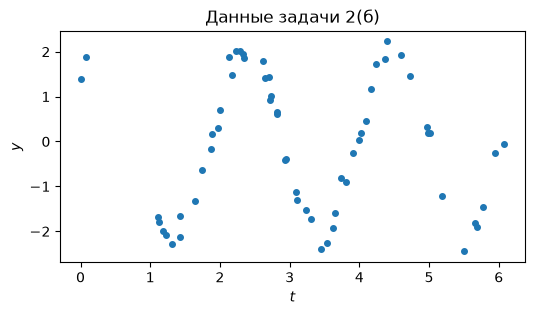

In [5]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Модель A.** Задача NLP, без ограничений. Цель периодическая по фазе: $f(x_1,x_2,x_3+2\pi)=f(x_1,x_2,x_3)$, также $f(-x_1,x_2,x_3+\pi)=f(x_1,x_2,x_3)$. Разные параметры могут задавать один и тот же сигнал.

Периодичности самой по себе недостаточно: постоянная функция тоже выпуклая. Здесь можно взять $x_2=0$ и выбрать $x_1=c \ne 0$ так, чтобы $Nc^2-2c\sum_i y_i \ne 0$. Тогда значения при $x_3=0$ и $x_3=\pi/2$ различаются, то есть получена непостоянная периодическая функция на прямой. Выпуклая функция на всей прямой не может быть непостоянной и периодической, поэтому задача невыпуклая.

**Модель B.** Задача QP, без ограничений. Пусть $A_{i1}=\sin(\omega t_i)$, $A_{i2}=\cos(\omega t_i)$. Тогда:

$f(x)=\dfrac12||Ax-y||_2^2,\quad \nabla f(x)=A^T(Ax-y),\quad \nabla^2 f(x)=A^T A$.

Для любого вектора $v$ имеем $v^T A^T Av=||Av||_2^2 \ge 0$, поэтому гессиан положительно полуопределен и задача выпуклая. Для данных ниже столбцы $A$ линейно независимы, поэтому минимум единственный.

**Мультистарт (пункт 2)**

Старт 1: f_A = 1.139273, f_B = 1.140764
Старт 2: f_A = 63.824908, f_B = 1.140764
Старт 3: f_A = 1.139273, f_B = 1.140764
Старт 4: f_A = 1.139273, f_B = 1.140764
Старт 5: f_A = 1.139273, f_B = 1.140764
Старт 6: f_A = 61.497273, f_B = 1.140764
Старт 7: f_A = 61.497273, f_B = 1.140764


Старт 8: f_A = 64.251776, f_B = 1.140764
Старт 9: f_A = 1.139273, f_B = 1.140764
Старт 10: f_A = 63.824905, f_B = 1.140764
Старт 11: f_A = 1.139273, f_B = 1.140764
Старт 12: f_A = 1.139273, f_B = 1.140764
Старт 13: f_A = 61.497273, f_B = 1.140764
Старт 14: f_A = 1.139273, f_B = 1.140764
Старт 15: f_A = 64.251776, f_B = 1.140764
Старт 16: f_A = 1.139273, f_B = 1.140764
Старт 17: f_A = 61.688171, f_B = 1.140764
Старт 18: f_A = 1.139273, f_B = 1.140764
Старт 19: f_A = 61.497273, f_B = 1.140764
Старт 20: f_A = 1.139273, f_B = 1.140764
Доля лучших стартов A: 55%
Доля лучших стартов B: 100%
Лучшее решение A: [-2.10139254  2.9966906  -2.44132862], f = 1.139273
Лучшее решение B: [1.6234269  1.33780773], f = 1.140764
Успешных запусков A: 18/20
Успешных запусков B: 20/20
Ранг матрицы A: 2
Амплитуда из B: 2.103626, фаза: 0.689243


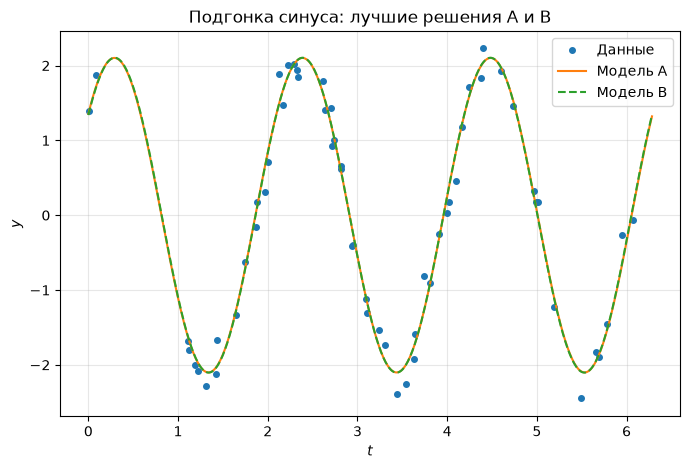

In [6]:
def model_a(t, x):
    return x[0] * np.sin(x[1] * t + x[2])

def model_b(t, x):
    return x[0] * np.sin(omega * t) + x[1] * np.cos(omega * t)

def f_a(x):
    return 0.5 * np.sum((model_a(t, x) - y)**2)

def f_b(x):
    return 0.5 * np.sum((model_b(t, x) - y)**2)

results_a = []
results_b = []

for i, start in enumerate(starts):
    result_a = minimize(f_a, start, method='BFGS')
    result_b = minimize(f_b, start[:2], method='BFGS')
    results_a.append(result_a)
    results_b.append(result_b)
    print(f'Старт {i+1}: f_A = {result_a.fun:.6f}, f_B = {result_b.fun:.6f}')

values_a = np.array([result.fun for result in results_a])
values_b = np.array([result.fun for result in results_b])
best_a = results_a[np.argmin(values_a)]
best_b = results_b[np.argmin(values_b)]
epsilon = 1e-6

print(f'Доля лучших стартов A: {np.mean(np.abs(values_a - best_a.fun) < epsilon):.0%}')
print(f'Доля лучших стартов B: {np.mean(np.abs(values_b - best_b.fun) < epsilon):.0%}')
print(f'Лучшее решение A: {best_a.x}, f = {best_a.fun:.6f}')
print(f'Лучшее решение B: {best_b.x}, f = {best_b.fun:.6f}')
print(f'Успешных запусков A: {sum(result.success for result in results_a)}/20')
print(f'Успешных запусков B: {sum(result.success for result in results_b)}/20')

A = np.column_stack([np.sin(omega * t), np.cos(omega * t)])
print(f'Ранг матрицы A: {np.linalg.matrix_rank(A)}')
amplitude = np.linalg.norm(best_b.x)
phase = np.arctan2(best_b.x[1], best_b.x[0])
print(f'Амплитуда из B: {amplitude:.6f}, фаза: {phase:.6f}')

t_plot = np.linspace(0, 2 * np.pi, 500)
plt.figure(figsize=(8, 5))
plt.plot(t, y, 'o', ms=4, label='Данные')
plt.plot(t_plot, model_a(t_plot, best_a.x), label='Модель A')
plt.plot(t_plot, model_b(t_plot, best_b.x), '--', label='Модель B')
plt.xlabel('$t$')
plt.ylabel('$y$')
plt.title('Подгонка синуса: лучшие решения A и B')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Объяснение (пункт 3)**

Для модели B все 20 стартов приходят к одному значению цели $f_B \approx 1.140764$. Для A наименьшее найденное значение $f_A \approx 1.139273$ получается в 11 из 20 запусков, то есть в 55%. Задача строго выпуклая, поэтому её локальный минимум является единственным глобальным минимумом. Для модели A значения по стартам различаются: выпуклости нет, поэтому локальный минимум не обязан быть глобальным. Доля лучших стартов считается с точностью $10^{-6}$ по значению цели.

Пусть решение B равно $(u,v)$. По формуле синуса суммы:

$R\sin(\omega t+\varphi)=R\cos\varphi\sin\omega t+R\sin\varphi\cos\omega t$.

Тогда $u=R\cos\varphi$, $v=R\sin\varphi$, откуда $R=\sqrt{u^2+v^2}$, $\varphi=\operatorname{atan2}(v,u)$. Параметры модели A получаются равными $(R,3,\varphi)$. Если $R=0$, фазу можно выбрать любой.

У модели A частота тоже является переменной, поэтому она может немного изменить её и лучше подогнать шум в обучающих данных. Модель B входит в A как частный случай с фиксированной частотой, поэтому глобальный минимум A не больше минимума B. Меньшая ошибка на этих данных не означает лучшего восстановления исходного сигнала: A может подгонять шум, а результат оптимизации зависит от старта. Кроме того, лучший результат мультистарта сам по себе не доказывает, что найден глобальный минимум A.

В запусках 2 и 10 для модели A BFGS сообщил о потере точности. Их итоговые значения выведены в общей таблице, но считать эти точки найденными локальными минимумами по одному результату метода нельзя. У B все 20 запусков завершились успешно.

## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

Пусть $u=P(p)$, $v=P(q)$. Запишем условие оптимальности для обеих проекций:

$(u-p)^T(v-u) \ge 0,$

$(v-q)^T(u-v) \ge 0$.

Сложим неравенства:

$((v-q)-(u-p))^T(u-v) \ge 0$.

Получаем $(p-q)^T(u-v)-||u-v||_2^2 \ge 0$, то есть:

$||u-v||_2^2 \le (p-q)^T(u-v) \le ||p-q||_2\,||u-v||_2$.

Последний переход - неравенство Коши–Буняковского. Если $u=v$, требуемое неравенство уже выполнено. Иначе делим на $||u-v||_2>0$:

$$||P(p)-P(q)||_2 \le ||p-q||_2.$$

Для существования проекции подразумевается, что множество непустое. Ниже проверим неравенство для 1000 случайных пар в $\mathbb{R}^3$ с точностью $10^{-12}$.

In [7]:
p_points = rng.uniform(-3, 3, (1000, 3))
q_points = rng.uniform(-3, 3, (1000, 3))
distances = np.linalg.norm(p_points - q_points, axis=1)

p_ball = p_points / np.maximum(1, np.linalg.norm(p_points, axis=1, keepdims=True))
q_ball = q_points / np.maximum(1, np.linalg.norm(q_points, axis=1, keepdims=True))
p_cube = np.clip(p_points, -1, 1)
q_cube = np.clip(q_points, -1, 1)

for title, p_projection, q_projection in [('Шар', p_ball, q_ball), ('Куб', p_cube, q_cube)]:
    projected_distances = np.linalg.norm(p_projection - q_projection, axis=1)
    difference = projected_distances - distances
    print(f'{title}: максимальная разность расстояний = {difference.max():.6f}')
    print(f'Количество нарушений: {np.sum(difference > 1e-12)}')

Шар: максимальная разность расстояний = -0.069007
Количество нарушений: 0
Куб: максимальная разность расстояний = 0.000000
Количество нарушений: 0


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).